
Running UMAP-like reduction with l2 distance...
Epoch 0
Epoch 100
Epoch 200


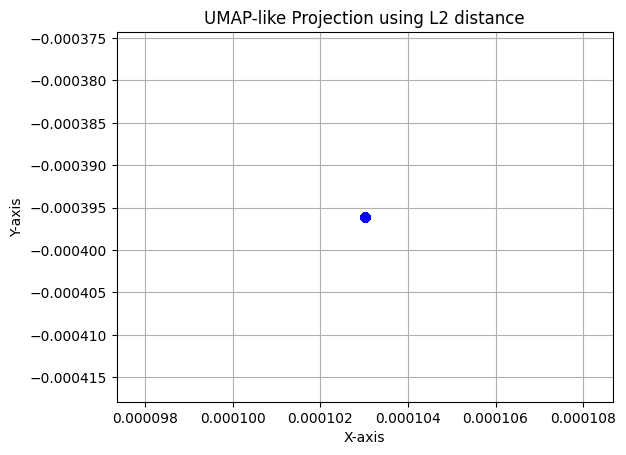


Running UMAP-like reduction with linf distance...
Epoch 0
Epoch 100
Epoch 200


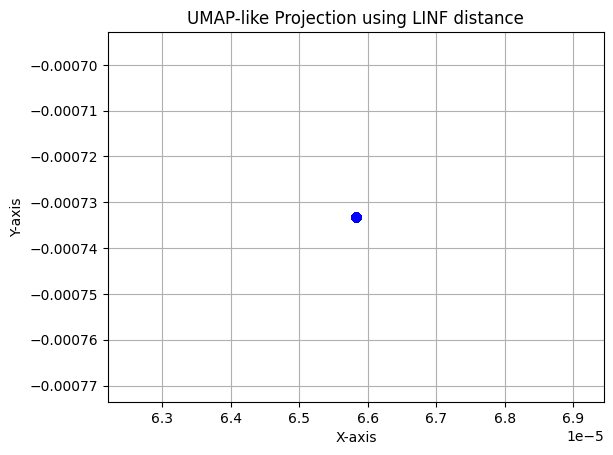

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
k = 10
n_epochs = 300
learning_rate = 0.5
dim = 2
np.random.seed(42)

# --- Generate Sample Data ---
X = np.random.randn(300, 20)  # 300 points in 3D

# --- Distance Matrix Functions ---
def pairwise_distance_matrix(X, metric='l2'):
    n = X.shape[0]
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(i+1, n):
            if metric == 'l2':
                d = np.linalg.norm(X[i] - X[j])
            elif metric == 'linf':
                d = np.max(np.abs(X[i] - X[j]))
            else:
                raise ValueError("Unsupported metric: choose 'l2' or 'linf'")
            D[i, j] = D[j, i] = d
    return D

# --- Graph & Fuzziness ---
def compute_sigmas_rhos(D, k):
    n = D.shape[0]
    sigmas = np.zeros(n)
    rhos = np.zeros(n)
    for i in range(n):
        d_sorted = np.sort(D[i, 1:])
        rhos[i] = d_sorted[0]
        lo, hi = 1e-3, 10.0
        for _ in range(50):
            mid = (lo + hi) / 2
            psum = np.sum(np.exp(-(d_sorted - rhos[i]) / mid))
            if np.abs(psum - np.log2(k)) < 1e-3:
                break
            if psum > np.log2(k):
                hi = mid
            else:
                lo = mid
        sigmas[i] = mid
    return sigmas, rhos

# --- Fuzzy Graph ---
def build_graph(D, sigmas, rhos, k):
    n = D.shape[0]
    P = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                pij = np.exp(-(D[i, j] - rhos[i]) / sigmas[i])
                if D[i, j] <= np.sort(D[i])[k]:
                    P[i, j] = pij
    P = P + P.T - P * P.T
    return P

# --- Low-dimensional probability function ---
def low_dim_prob(dist, a=1.0, b=1.0):
    return 1 / (1 + a * dist**(2*b))

# --- SGD Optimization ---
def optimize_embedding(P, dim=2, n_epochs=300, lr=0.5):
    n = P.shape[0]
    Y = np.random.normal(0, 0.01, (n, dim))
    for epoch in range(n_epochs):
        for i in range(n):
            for j in range(n):
                if P[i, j] > 0:
                    dist = np.linalg.norm(Y[i] - Y[j])
                    qij = low_dim_prob(dist)
                    grad = 2 * (P[i, j] - qij) * (Y[i] - Y[j])
                    Y[i] += lr * grad
                    Y[j] -= lr * grad
        if epoch % 100 == 0:
            print(f"Epoch {epoch}")
    return Y

# --- Main function ---
def run_umap_demo(metric='l2'):
    print(f"\nRunning UMAP-like reduction with {metric} distance...")
    D = pairwise_distance_matrix(X, metric)
    sigmas, rhos = compute_sigmas_rhos(D, k)
    P = build_graph(D, sigmas, rhos, k)
    Y = optimize_embedding(P, dim=dim, n_epochs=n_epochs, lr=learning_rate)

    plt.scatter(Y[:,0], Y[:,1], c='blue', alpha=0.7)
    plt.title(f"UMAP-like Projection using {metric.upper()} distance")
    plt.xlabel("X-axis")
    plt.ylabel("Y-axis")
    plt.grid(True)
    plt.show()

# --- Run both metrics ---
run_umap_demo('l2')
run_umap_demo('linf')


c:\Users\PRAKASH\AppData\Local\anaconda3\envs\EEG_analysis\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\PRAKASH\AppData\Local\anaconda3\envs\EEG_analysis\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\PRAKASH\AppData\Local\anaconda3\envs\EEG_analysis\Lib\site-packages\sklearn\manifold\_isomap.py:383: UserWarning: The number of connected components of the neighbors graph is 4 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
c:\Users\PRAKASH\AppData\Local\anaconda3\envs\EEG_analysis\Lib\site-packages\scipy\sparse\_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil

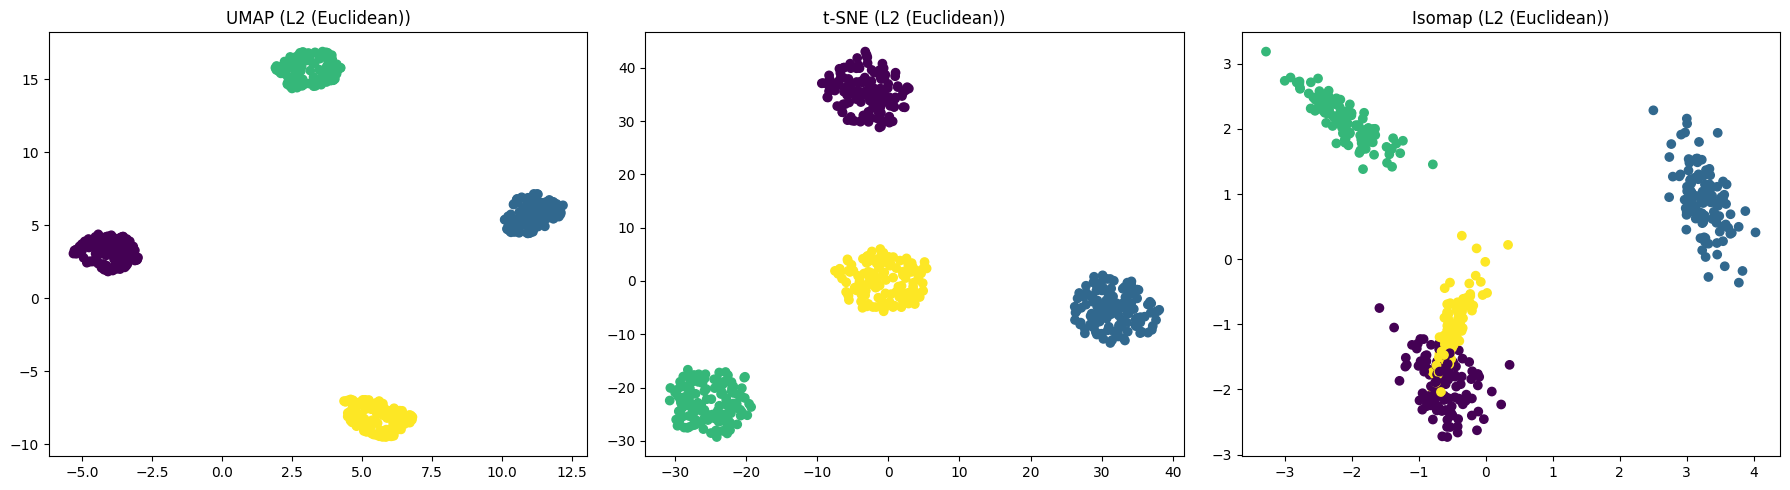

c:\Users\PRAKASH\AppData\Local\anaconda3\envs\EEG_analysis\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\PRAKASH\AppData\Local\anaconda3\envs\EEG_analysis\Lib\site-packages\sklearn\manifold\_isomap.py:383: UserWarning: The number of connected components of the neighbors graph is 4 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
c:\Users\PRAKASH\AppData\Local\anaconda3\envs\EEG_analysis\Lib\site-packages\scipy\sparse\_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_intXint(row, col, x.flat[0])
c:\Users\PRAKASH\AppData\Local\anaconda3\envs\EEG_analysis\Lib\site-packages\scipy\sparse\_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more eff

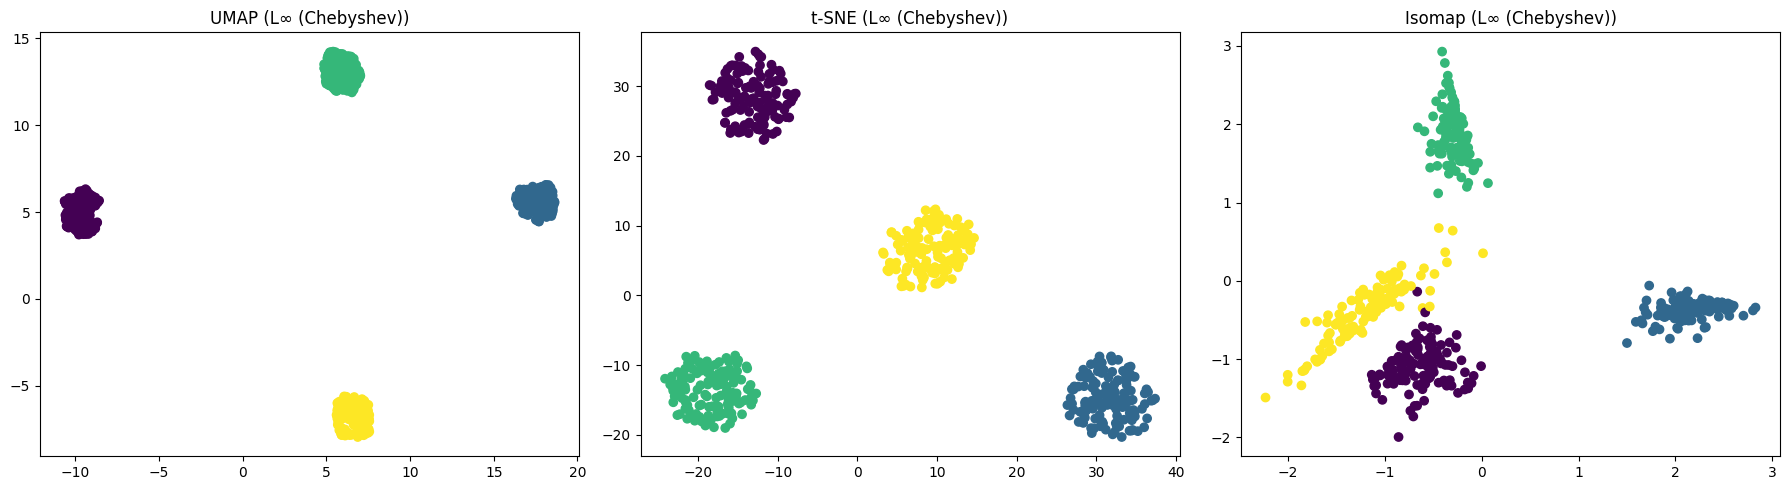

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.manifold import TSNE, Isomap
import umap
from sklearn.preprocessing import StandardScaler

# --- Generate synthetic high-dimensional data ---
X, y = make_blobs(n_samples=500, centers=4, n_features=5, random_state=42)
X = StandardScaler().fit_transform(X)

# --- Run dimensionality reduction methods ---
def run_reductions(X, metric='euclidean'):
    reducer_umap = umap.UMAP(n_neighbors=15, min_dist=0.1, metric=metric, random_state=42)
    embedding_umap = reducer_umap.fit_transform(X)

    tsne = TSNE(n_components=2, metric=metric, random_state=42)
    embedding_tsne = tsne.fit_transform(X)

    isomap = Isomap(n_neighbors=10, metric=metric)
    embedding_isomap = isomap.fit_transform(X)

    return embedding_umap, embedding_tsne, embedding_isomap

# --- Visualize results ---
def plot_embeddings(embedding_umap, embedding_tsne, embedding_isomap, title_suffix):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].scatter(embedding_umap[:,0], embedding_umap[:,1], c=y, cmap='viridis')
    axes[0].set_title(f'UMAP ({title_suffix})')

    axes[1].scatter(embedding_tsne[:,0], embedding_tsne[:,1], c=y, cmap='viridis')
    axes[1].set_title(f't-SNE ({title_suffix})')

    axes[2].scatter(embedding_isomap[:,0], embedding_isomap[:,1], c=y, cmap='viridis')
    axes[2].set_title(f'Isomap ({title_suffix})')

    plt.tight_layout()
    plt.show()

# --- Run for L2 (Euclidean) ---
e_umap, e_tsne, e_isomap = run_reductions(X, metric='euclidean')
plot_embeddings(e_umap, e_tsne, e_isomap, 'L2 (Euclidean)')

# --- Run for L∞ (Chebyshev) ---
inf_umap, inf_tsne, inf_isomap = run_reductions(X, metric='chebyshev')
plot_embeddings(inf_umap, inf_tsne, inf_isomap, 'L∞ (Chebyshev)')


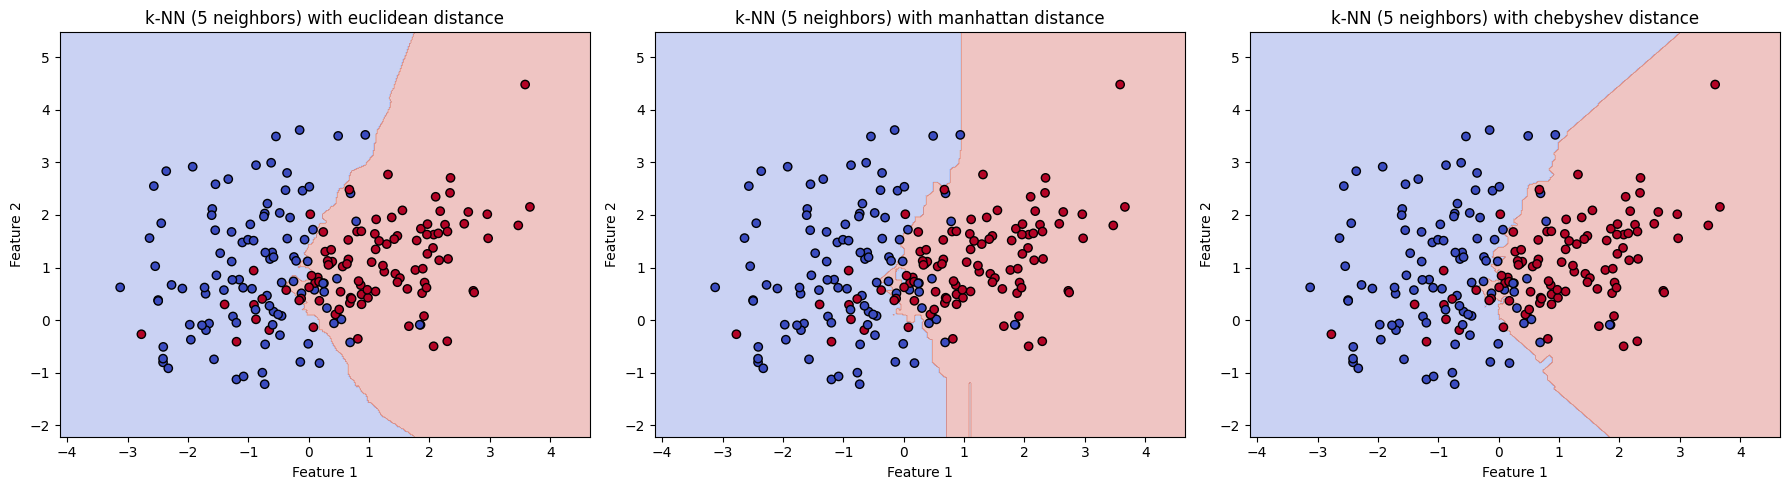

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import make_classification

# --- Create synthetic 2D dataset ---
X, y = make_classification(
    n_samples=200, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, n_classes=2, random_state=42
)

# --- Create mesh grid for plotting decision boundaries ---
h = 0.02
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# --- Define distance metrics to compare ---
metrics = ['euclidean', 'manhattan', 'chebyshev']

plt.figure(figsize=(18, 5))

for i, metric in enumerate(metrics):
    # --- Train k-NN model with each metric ---
    knn = KNeighborsClassifier(n_neighbors=15, metric=metric)
    knn.fit(X, y)
    
    # --- Predict over mesh grid ---
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # --- Plot ---
    plt.subplot(1, 3, i+1)
    plt.contourf(xx, yy, Z, cmap='coolwarm', alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k')
    plt.title(f"k-NN (5 neighbors) with {metric} distance")
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np 
from sklearn.preprocessing import StandardScaler
x = np.array([[3,4,5],[2,3,6],[2,3,1]])
scaler = StandardScaler()
df_standardized = scaler.fit_transform(x)
print(x, df_standardized)


[[3 4 5]
 [2 3 6]
 [2 3 1]] [[ 1.41421356  1.41421356  0.46291005]
 [-0.70710678 -0.70710678  0.9258201 ]
 [-0.70710678 -0.70710678 -1.38873015]]


In [16]:
df_standardized[0] 

array([1.41421356, 1.41421356, 0.46291005])

In [17]:
from scipy.spatial import distance

A = df_standardized[0] 
B = df_standardized[1] 
C = df_standardized[2] 

print("A–B L2:", distance.euclidean(A, B))
print("A–C L2:", distance.euclidean(A, C))
print("B–C L2:", distance.euclidean(B, C))

print("A–B L1:", distance.cityblock(A, B))
print("A–C L1:", distance.cityblock(A, C))
print("B–C L1:", distance.cityblock(B, C))

print("A–B Chebyshev:", distance.chebyshev(A, B))
print("A–C Chebyshev:", distance.chebyshev(A, C))
print("B–C Chebyshev:", distance.chebyshev(B, C))


A–B L2: 3.035504194410825
A–C L2: 3.5254179083580186
B–C L2: 2.3145502494313783
A–B L1: 4.70555073700556
A–C L1: 6.094280886664388
B–C L1: 2.3145502494313783
A–B Chebyshev: 2.1213203435596424
A–C Chebyshev: 2.1213203435596424
B–C Chebyshev: 2.3145502494313783
